# 03 — Descriptive analysis

Describes the HyCAN-DB corpus before any hypothesis is tested (manual §12.1): what is in it, how it is distributed, and which rows are eligible for aggregation under the §12.3 filter. Every number here is computed from `data/raw/measurements_v0.1.csv` via `hycan.load` / `hycan.meta`; nothing is typed by hand.

In [1]:
# Setup: find the repo root so this notebook runs from anywhere, then import.
import os, sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
_d = Path.cwd()
while _d != _d.parent and not (_d / 'pyproject.toml').exists():
    _d = _d.parent
os.chdir(_d); sys.path.insert(0, str(_d / 'src'))
import pandas as pd
import matplotlib.pyplot as plt
from hycan.load import load_dataset, analysis_subset
from hycan import meta
from hycan.plotting import set_house_style
set_house_style()
df = load_dataset()
print('dataset:', df.shape[0], 'rows,', df['paper_id'].nunique(), 'papers')

dataset: 521 rows, 51 papers


## Corpus summary
Totals across the whole dataset, and the analysis subset that survives the §12.3 filter (isothermal, exact, fully-conditioned, uptake-bearing).

In [2]:
s = meta.descriptive_summary(df)
for k, v in s.items():
    print(f'{k:22s}: {v}')

dataset_rows          : 521
dataset_papers        : 51
analysis_rows         : 431
analysis_papers       : 45
wt_pct_rows           : 419
tier_counts_full      : {'A': 92, 'B': 358, 'C': 54, 'D': 17}
material_classes      : 13
year_min              : 1999
year_max              : 2025


The corpus is **521 rows / 51 papers / 13 material classes, 1999–2025**. The §12.3 filter keeps **431 rows / 45 papers** for aggregation; 419 carry a wt% uptake (the target for every wt%-based figure and the model). The 90 excluded rows are non-isothermal, bounded, unstated-condition, or characterization-only — they belong in the dataset but not in a mean.

## Material composition (analysis subset)

material_class
activated_carbon          206
composite                  47
doped_carbon               38
reduced_graphene_oxide     27
MWCNT                      27
carbide_derived_carbon     23
templated_carbon           18
SWCNT                      15
other                      13
carbon_nanofiber            9
graphene                    5
graphene_oxide              2
carbon_aerogel              1


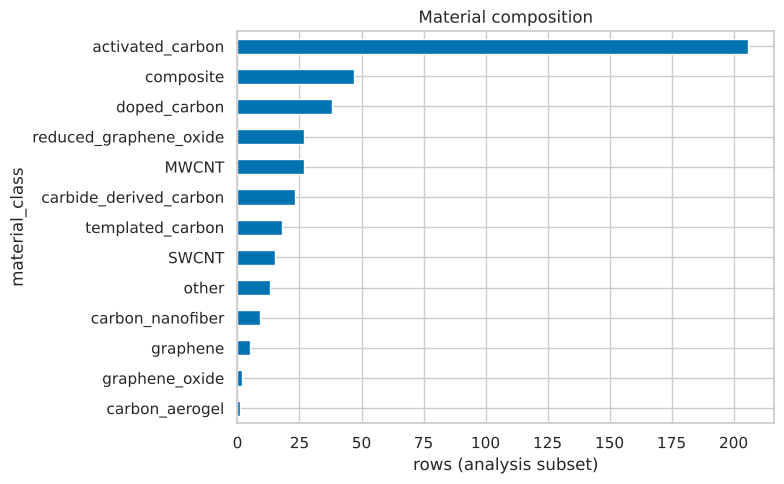

In [3]:
sub = analysis_subset(df)
comp = sub['material_class'].value_counts()
print(comp.to_string())
ax = comp.plot.barh(figsize=(8,5)); ax.invert_yaxis()
ax.set_xlabel('rows (analysis subset)'); ax.set_title('Material composition')
plt.tight_layout(); plt.show()

Activated carbons dominate the analysis subset, followed by composites, doped carbons, and the nanotube/graphene families. See `figures/fig1_corpus_map` for the per-year breakdown and `figures/fig2_condition_space` for the temperature–pressure coverage.

## Uptake distribution and reproducibility tiers

uptake wt% — describe:
count    419.000
mean       2.196
std        1.971
min        0.000
25%        0.430
50%        1.880
75%        3.110
max        9.800

tier counts (wt% subset): {'B': 303, 'A': 87, 'C': 21, 'D': 8}


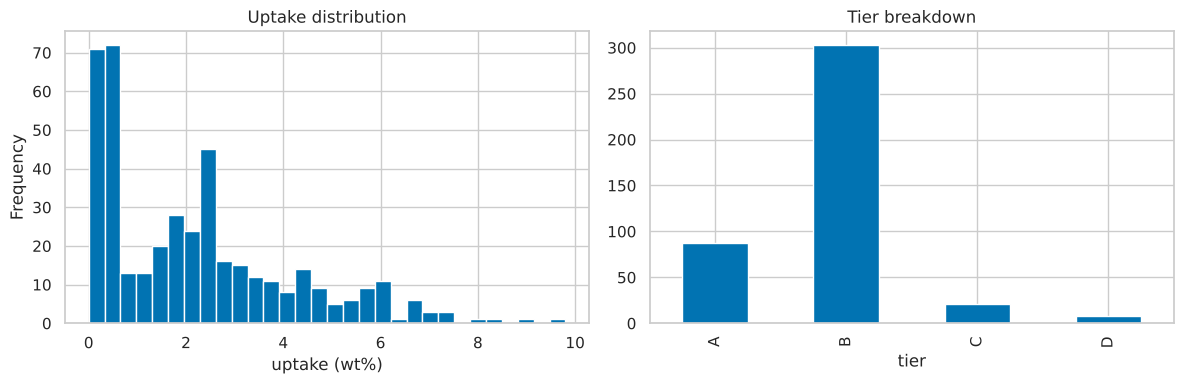

In [4]:
wt = analysis_subset(df, require_wt_pct=True).copy()
wt['uptake_wt_pct'] = pd.to_numeric(wt['uptake_wt_pct'], errors='coerce')
print('uptake wt% — describe:')
print(wt['uptake_wt_pct'].describe().round(3).to_string())
print('\ntier counts (wt% subset):', wt['reproducibility_tier'].value_counts().to_dict())
fig, ax = plt.subplots(1, 2, figsize=(12,4))
wt['uptake_wt_pct'].plot.hist(bins=30, ax=ax[0]); ax[0].set_xlabel('uptake (wt%)'); ax[0].set_title('Uptake distribution')
wt['reproducibility_tier'].value_counts().reindex(['A','B','C','D']).plot.bar(ax=ax[1]); ax[1].set_title('Tier breakdown'); ax[1].set_xlabel('tier')
plt.tight_layout(); plt.show()

## Observations
- The corpus spans a quarter-century and thirteen carbon families but is weighted toward activated carbons and the 77 K regime (see Fig 2).
- Most uptake values are modest (median a few wt%); the tail of high values is where the reproducibility tiering earns its place.
- These are descriptions, not findings. The Chahine-rule test and publication-bias analysis are in `04_meta_analysis.ipynb`.